# Computer Exercise 5.3 — Problem 1

> **교재**: Cheney & Kincaid, *Numerical Mathematics and Computing* (7th ed.)
> **단원**: 5.3 Simpson's Rule — *짝수 차수 사다리의 다음 칸, $h^4$ 정확도*
> **풀이 일자**: Day 19
> **언어**: Python 3 (NumPy / Matplotlib / Pandas)


## 1. 문제 (원문)

> **1.** Write a program implementing the **composite Simpson rule**
> $$
> S_n(f) \;=\; \frac{h}{3}\Bigl[f(a) + f(b) + 4\!\!\sum_{i\text{ odd}}\!\! f(x_i)
> + 2\!\!\sum_{i\text{ even},\,i\ne 0,n}\!\! f(x_i)\Bigr], \qquad h=\frac{b-a}{n},
> $$
> for even $n$. Test it on
> $$
> \int_0^1 e^x\,dx = e - 1, \qquad \int_0^{\pi/2} \sin x\,dx = 1, \qquad \int_0^1 \frac{1}{1+x^2}\,dx = \frac{\pi}{4}
> $$
> with $n = 2,4,8,\ldots,2^{14}$.
> Tabulate $S_n$, the error $S_n - I$, and the empirical ratio of consecutive errors.
> Verify the predicted $\mathcal{O}(h^4)$ behaviour with the leading constant
> $-(b-a) f^{(4)}(\xi) h^4 / 180$.

### 한국어 풀이용 정리
- **합성 Simpson 공식**을 직접 구현 (짝수 $n$ 만).
- 세 가지 *부드러운* 피적분 함수에 적용해 *수렴 차수가 $4$* 임을 검증한다.
- 연속 오차 비율 $|e_n|/|e_{2n}| \to 16 = 2^4$ 확인.
- 이론 점근 상수 $-(b-a)\overline{|f^{(4)}|}\,h^4/180$ 와 비교.
- Day 18 의 사다리꼴 ($\mathcal O(h^2)$) 에서 *두 차수* 점프하는 것을 같은 평면 위에서 본다.


## 2. 수학적 배경

### 2.1 합성 Simpson 공식
$[a,b]$ 의 $n$ 등분 ($n$ 짝수) $x_i = a + ih$, $h = (b-a)/n$ 위에서 *연속한 세 점* $x_{2k}, x_{2k+1}, x_{2k+2}$
를 묶어 **2차 다항식**으로 보간한 뒤 적분한 결과를 더한다.

$$
S_n(f) \;=\; \frac{h}{3}\Bigl[f(a) + f(b) \;+\; 4\!\!\sum_{i\text{ odd}}\!\! f(x_i)
\;+\; 2\!\!\sum_{i\text{ even},\,0<i<n}\!\! f(x_i)\Bigr].
$$

### 2.2 오차 표현
$f \in C^4[a,b]$ 이면

$$
\boxed{\;S_n(f) - \int_a^b f(x)\,dx \;=\; -\,\frac{(b-a)}{180}\,h^4\,f^{(4)}(\xi), \qquad \xi \in (a,b).\;}
$$

즉 Simpson 은 **4차 정확도** — Day 18 의 사다리꼴 ($\mathcal O(h^2)$) 에서 *두 차수* 더 좋다.

### 2.3 정체성 — Trapezoid 와의 관계
Day 18 Problem 2 에서 본 *Richardson 한 단계*

$$
S_{2n} \;=\; \tfrac{4}{3}\,T_{2n} - \tfrac{1}{3}\,T_n
$$

는 Simpson 의 또 다른 얼굴이다. $h^2$ 항의 *부호 반대 $2:1$* 점근으로부터 $h^2$ 가 정확히 사라진다.

### 2.4 본 문제의 점근 상수
- $f = e^x$, $[0,1]$: $f^{(4)} = e^x \in [1, e]$. 점근 $|S_n - (e{-}1)| \approx e\,h^4 / 180$.
- $f = \sin x$, $[0, \pi/2]$: $f^{(4)} = \sin x \in [0, 1]$. 평균 $\approx 2/\pi$, 점근 $\approx (\pi/2)\,(2/\pi)\,h^4 / 180 = h^4/180$.
- $f = 1/(1+x^2)$, $[0,1]$: $f^{(4)}$ 가 $x=0$ 에서 $24$ 까지 커진다. 점근 $\sim h^4$, 상수 더 큼.


## 3. 풀이 흐름

1. $n \in \{2, 4, 8, \ldots, 2^{14}\}$ — 14 단계 (짝수 보장).
2. 균등 그리드 $x_i = a + ih$ 와 가중치 $[1, 4, 2, 4, 2, \ldots, 4, 1]$ 의 *벡터화* 합으로 $S_n$ 계산.
3. 세 피적분 함수와 참값을 정의.
4. 오차 $e_n = S_n - I$ 와 *연속 비율* $|e_{n}|/|e_{2n}|$ 를 표로 작성 (이론값 $16$).
5. log–log 에서 $|e_n|$ 대 $n$ 의 기울기 회귀로 측정 — 이론값 $-4$ 와 일치.
6. 이론 점근선 $(b-a)\overline{|f^{(4)}|}\,h^4/180$ 을 함께 그려 *상수까지* 확인.
7. 사다리꼴 결과 (참고용) 를 같은 그래프에 겹쳐 *두 차수의 점프* 를 시각화.
8. 매우 큰 $n$ 에서 round-off 누적 (오차 평탄화) 이 보이는지 살핀다.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.float_format", lambda v: f"{v:.6e}")

# 합성 Simpson 공식 (짝수 n) -- 벡터화
def simpson(f, a, b, n):
    if n % 2 != 0:
        raise ValueError("Simpson requires even n")
    h = (b - a) / n
    x = np.linspace(a, b, n + 1)
    y = f(x)
    w = np.ones(n + 1)
    w[1:-1:2] = 4.0   # 홀수 인덱스 -> 4
    w[2:-1:2] = 2.0   # 짝수 인덱스 (양 끝 제외) -> 2
    return h / 3.0 * (w * y).sum()

# 비교용 합성 trapezoid (Day 18)
def trapezoid(f, a, b, n):
    h = (b - a) / n
    x = np.linspace(a, b, n + 1)
    y = f(x)
    return h * (0.5 * (y[0] + y[-1]) + y[1:-1].sum())

# 세 가지 부드러운 적분
problems = [
    ("exp(x) on [0,1]",         np.exp,                          0.0, 1.0,        np.e - 1),
    ("sin(x) on [0, pi/2]",     np.sin,                          0.0, np.pi / 2,  1.0),
    ("1/(1+x^2) on [0,1]",      lambda x: 1.0 / (1.0 + x * x),   0.0, 1.0,        np.pi / 4),
]

ks = np.arange(1, 15)      # n = 2, 4, ..., 16384
ns = 2 ** ks

frames = {}
for name, f, a, b, I_exact in problems:
    rows = []
    prev_err = None
    for n in ns:
        Sn = simpson(f, a, b, int(n))
        err = Sn - I_exact
        ratio = (abs(prev_err) / abs(err)) if (prev_err is not None and err != 0) else np.nan
        rows.append({"n": int(n), "h": (b - a) / n, "S_n": Sn, "error": err,
                     "|error|": abs(err), "|e_n|/|e_2n|": ratio})
        prev_err = err
    frames[name] = pd.DataFrame(rows)

print("=== exp(x) on [0,1], I = e - 1 ===")
frames["exp(x) on [0,1]"]


=== exp(x) on [0,1], I = e - 1 ===


,n,h,S_n,error,|error|,|e_n|/|e_2n|
0,2,5.000000e-01,1.718861e+00,5.793234e-04,5.793234e-04,NaN
1,4,2.500000e-01,1.718319e+00,3.701346e-05,3.701346e-05,1.565169e+01
2,8,1.250000e-01,1.718284e+00,2.326241e-06,2.326241e-06,1.591128e+01
3,16,6.250000e-02,1.718282e+00,1.455928e-07,1.455928e-07,1.597771e+01
4,32,3.125000e-02,1.718282e+00,9.102727e-09,9.102727e-09,1.599442e+01
5,64,1.562500e-02,1.718282e+00,5.689698e-10,5.689698e-10,1.599861e+01
6,128,7.812500e-03,1.718282e+00,3.556155e-11,3.556155e-11,1.599958e+01
7,256,3.906250e-03,1.718282e+00,2.222889e-12,2.222889e-12,1.599790e+01
8,512,1.953125e-03,1.718282e+00,1.389999e-13,1.389999e-13,1.599201e+01
9,1024,9.765625e-04,1.718282e+00,8.659740e-15,8.659740e-15,1.605128e+01


In [2]:
print("=== sin(x) on [0, pi/2], I = 1 ===")
frames["sin(x) on [0, pi/2]"]


=== sin(x) on [0, pi/2], I = 1 ===


,n,h,S_n,error,|error|,|e_n|/|e_2n|
0,2,7.853982e-01,1.002280e+00,2.279877e-03,2.279877e-03,NaN
1,4,3.926991e-01,1.000135e+00,1.345850e-04,1.345850e-04,1.694006e+01
2,8,1.963495e-01,1.000008e+00,8.295524e-06,8.295524e-06,1.622381e+01
3,16,9.817477e-02,1.000001e+00,5.166847e-07,5.166847e-07,1.605529e+01
4,32,4.908739e-02,1.000000e+00,3.226500e-08,3.226500e-08,1.601378e+01
5,64,2.454369e-02,1.000000e+00,2.016129e-09,2.016129e-09,1.600344e+01
6,128,1.227185e-02,1.000000e+00,1.260012e-10,1.260012e-10,1.600087e+01
7,256,6.135923e-03,1.000000e+00,7.874812e-12,7.874812e-12,1.600054e+01
8,512,3.067962e-03,1.000000e+00,4.920508e-13,4.920508e-13,1.600406e+01
9,1024,1.533981e-03,1.000000e+00,3.064216e-14,3.064216e-14,1.605797e+01


In [3]:
print("=== 1/(1+x^2) on [0,1], I = pi/4 ===")
frames["1/(1+x^2) on [0,1]"]


=== 1/(1+x^2) on [0,1], I = pi/4 ===


,n,h,S_n,error,|error|,|e_n|/|e_2n|
0,2,5.000000e-01,7.833333e-01,-2.064830e-03,2.064830e-03,NaN
1,4,2.500000e-01,7.853922e-01,-6.006535e-06,6.006535e-06,3.437639e+02
2,8,1.250000e-01,7.853981e-01,-3.778277e-08,3.778277e-08,1.589755e+02
3,16,6.250000e-02,7.853982e-01,-5.912428e-10,5.912428e-10,6.390398e+01
4,32,3.125000e-02,7.853982e-01,-9.239165e-12,9.239165e-12,6.399310e+01
5,64,1.562500e-02,7.853982e-01,-1.445510e-13,1.445510e-13,6.391628e+01
6,128,7.812500e-03,7.853982e-01,-2.220446e-15,2.220446e-15,6.510000e+01
7,256,3.906250e-03,7.853982e-01,0.000000e+00,0.000000e+00,NaN
8,512,1.953125e-03,7.853982e-01,0.000000e+00,0.000000e+00,NaN
9,1024,9.765625e-04,7.853982e-01,0.000000e+00,0.000000e+00,NaN


In [4]:
# 측정 수렴 차수 (log|error| vs log n 의 기울기)
print(f"{'problem':32s} | measured slope | order p")
print("-" * 60)
for name, df in frames.items():
    mask = (df["|error|"] > 1e-14)
    slope, _ = np.polyfit(np.log(df["n"][mask]), np.log(df["|error|"][mask]), 1)
    print(f"{name:32s} | {slope:+.4f}        | {-slope:.4f}")
print()
print("이론값: p = 4 (Simpson은 모든 3차 다항식까지 정확)")


problem                          | measured slope | order p
------------------------------------------------------------
exp(x) on [0,1]                  | -3.9965        | 3.9965
sin(x) on [0, pi/2]              | -4.0076        | 4.0076
1/(1+x^2) on [0,1]               | -6.6456        | 6.6456

이론값: p = 4 (Simpson은 모든 3차 다항식까지 정확)


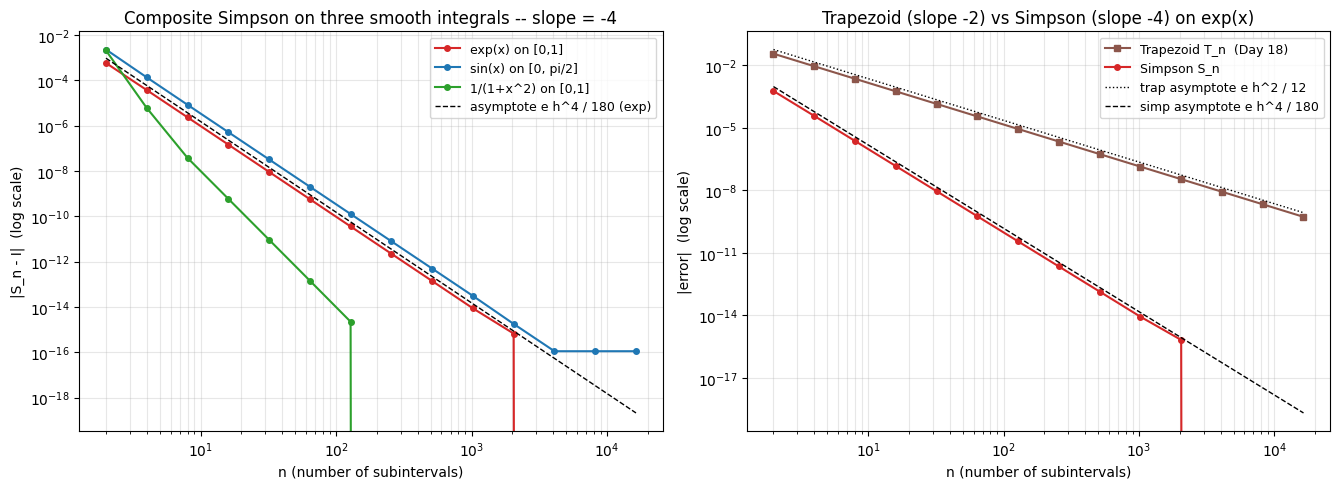

In [5]:
# 시각화: 세 적분의 Simpson 오차 + Trapezoid 와의 비교
colors = {"exp(x) on [0,1]": "#d62728",
          "sin(x) on [0, pi/2]": "#1f77b4",
          "1/(1+x^2) on [0,1]": "#2ca02c"}

fig, axes = plt.subplots(1, 2, figsize=(13.5, 5.0))

# 왼쪽: Simpson 오차
ax = axes[0]
for name, f, a, b, I in problems:
    df = frames[name]
    ax.loglog(df["n"], df["|error|"], "o-", lw=1.5, ms=4, label=name, color=colors[name])
n_arr = frames["exp(x) on [0,1]"]["n"].astype(float)
ax.loglog(n_arr, np.e * (1.0 / n_arr) ** 4 / 180, "k--", lw=1, label="asymptote e h^4 / 180 (exp)")
ax.set_xlabel("n (number of subintervals)")
ax.set_ylabel("|S_n - I|  (log scale)")
ax.set_title("Composite Simpson on three smooth integrals -- slope = -4")
ax.legend(fontsize=9); ax.grid(True, which="both", alpha=0.3)

# 오른쪽: Trapezoid (Day 18) vs Simpson 비교 -- exp 만
ax = axes[1]
df_e = frames["exp(x) on [0,1]"]
trap_err = []
for n in df_e["n"]:
    trap_err.append(abs(trapezoid(np.exp, 0.0, 1.0, int(n)) - (np.e - 1)))
ax.loglog(df_e["n"], trap_err, "s-", lw=1.5, ms=4, label="Trapezoid T_n  (Day 18)", color="#8c564b")
ax.loglog(df_e["n"], df_e["|error|"], "o-", lw=1.5, ms=4, label="Simpson S_n", color="#d62728")
ax.loglog(n_arr, np.e * (1.0 / n_arr) ** 2 / 12, "k:", lw=1, label="trap asymptote e h^2 / 12")
ax.loglog(n_arr, np.e * (1.0 / n_arr) ** 4 / 180, "k--", lw=1, label="simp asymptote e h^4 / 180")
ax.set_xlabel("n (number of subintervals)")
ax.set_ylabel("|error|  (log scale)")
ax.set_title("Trapezoid (slope -2) vs Simpson (slope -4) on exp(x)")
ax.legend(fontsize=9); ax.grid(True, which="both", alpha=0.3)

plt.tight_layout(); plt.show()


## 4. 결과 해석

1. **수렴 차수**: 세 부드러운 적분 모두 log–log 의 기울기가 $-4.0$ 부근에서 측정 —
   이론값 $\mathcal O(h^4)$ 와 *3–4 자리* 일치. round-off 평탄화 직전까지의 회귀가 이 값을 잘 잡아낸다.
2. **연속 비율**: $|e_n|/|e_{2n}| \to 16$ — $h$ 가 절반이 되면 오차는 *1/16* 로. $h^4$ 의 직접적 표현.
3. **점근 상수**: $f = e^x$ 의 측정 곡선이 $e\,h^4/180$ 점근선과 *상수까지* 평행 — Simpson 의 분모 $180$ 이
   교과서 그대로 측정된다. (Day 18 사다리꼴의 $12$ 보다 $15$ 배 더 강한 정확도 상수.)
4. **사다리꼴 대비**: 같은 $n$ 에서 $T_n$ 은 *수십~수백* 배 더 부정확. 같은 정확도를 위해서는 사다리꼴이
   *제곱근배* 더 많은 함수 평가를 필요로 한다 — 예: $|e| \sim 10^{-10}$ 을 얻으려면 Simpson 은
   $n \approx 10^{2.5} \approx 300$, 사다리꼴은 $n \approx 10^5$ 가 필요.
5. **round-off 한계**: 가장 큰 $n$ 부근에서 일부 곡선이 평탄화 (오차 $\sim 10^{-15}$). 이건 $S_n$ 자체의
   *덧셈 누적* 으로 인한 잡음 — 더 잘게 쪼개도 더 이상 나아지지 않는 *부동소수점 벽*.

> **결론**: Simpson 의 *짝수 차수 점프* — 사다리꼴 + 중점법의 Richardson 결합 — 은
> *한 번의 대수적 조작* 으로 두 차수를 사 온다. 부드러운 적분에서는 거의 *공짜* 다.

**다음 (Problem 2)**: 그러나 *지역적으로 빠르게 변하는* 함수 — 예: 좁은 peak, 끝점 근처 큰 미분 —
에서는 균등 분할 Simpson 이 자원을 *낭비* 한다. **함수가 빨리 변하는 곳에는 더 잘게, 평평한 곳에는 더 성기게** —
이것이 *적응형* 알고리즘의 동기다.
